## Data deleted Models ##

Loading data

In [68]:
import pandas as pd

data_deleted = pd.read_parquet("data_processed/data_deleted.parquet")

print(len(data_deleted))
print(data_deleted.columns.tolist())
print(data_deleted.head(5))

482188
['puuid', 'match_id', 'team', 'role', 'champion', 'traj_len', 'x0', 'y0', 'x1', 'y1', 'x2', 'y2', 'x3', 'y3', 'x4', 'y4', 'x5', 'y5', 'x6', 'y6', 'x7', 'y7', 'x8', 'y8', 'x9', 'y9', 'x10', 'y10', 'x11', 'y11', 'x12', 'y12', 'x13', 'y13', 'x14', 'y14', 'x15', 'y15', 'x16', 'y16', 'x17', 'y17', 'x18', 'y18', 'x19', 'y19', 'x20', 'y20', 'x21', 'y21', 'x22', 'y22', 'x23', 'y23', 'x24', 'y24', 'x25', 'y25', 'x26', 'y26', 'x27', 'y27', 'x28', 'y28', 'x29', 'y29', 'x30', 'y30', 'x31', 'y31', 'x32', 'y32', 'x33', 'y33', 'x34', 'y34', 'x35', 'y35', 'x36', 'y36', 'x37', 'y37', 'x38', 'y38', 'x39', 'y39', 'x40', 'y40', 'x41', 'y41', 'x42', 'y42', 'x43', 'y43', 'x44', 'y44', 'x45', 'y45', 'x46', 'y46', 'x47', 'y47', 'x48', 'y48', 'x49', 'y49', 'x50', 'y50', 'x51', 'y51', 'x52', 'y52', 'x53', 'y53', 'x54', 'y54', 'x55', 'y55', 'x56', 'y56', 'x57', 'y57', 'x58', 'y58', 'x59', 'y59']
                                               puuid         match_id  team  \
0  mCG4W3ohaS1yeYuEIpAiXCgHPyOb_

Baseline: Champion -> Role

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


# Mapping
data_baseline = data_deleted[['champion', 'role']]

data_train, data_test = train_test_split(data_baseline, test_size=0.2)

model_map = data_train.groupby('champion')['role'].agg(lambda x: x.mode()[0])
y_pred_map = data_test['champion'].map(model_map)

# Logistic Regression

X = data_deleted[['champion']].copy()
y = data_deleted['role']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

pipeline = Pipeline([
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore')),
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=100, random_state=42))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

# Models review
print("="*50)
print("MAPPING BASELINE")
print("="*50)
acc_map = accuracy_score(data_test['role'], y_pred_map)
print(f"Accuracy: {acc_map:.4f}")
print("\nClassification Report:")
print(classification_report(data_test['role'], y_pred_map))

print("\n" + "="*50)
print("LOGISTIC REGRESSION")
print("="*50)
acc_lr = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc_lr:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\n" + "="*50)
print("PODSUMOWANIE")
print("="*50)
print(f"Mapping:     {acc_map:.4f}")
print(f"Logistic R.: {acc_lr:.4f}")
print(f"Difference:     {(acc_lr - acc_map):.4f}")

MAPPING BASELINE
Accuracy: 0.8344

Classification Report:
              precision    recall  f1-score   support

      BOTTOM       0.91      0.93      0.92     19306
      JUNGLE       0.78      0.84      0.81     19200
      MIDDLE       0.77      0.73      0.75     19124
         TOP       0.80      0.75      0.78     19525
     UTILITY       0.90      0.91      0.91     19283

    accuracy                           0.83     96438
   macro avg       0.83      0.83      0.83     96438
weighted avg       0.83      0.83      0.83     96438


LOGISTIC REGRESSION
Accuracy: 0.8347

Classification Report:
              precision    recall  f1-score   support

      BOTTOM       0.91      0.93      0.92     19295
      JUNGLE       0.78      0.84      0.81     19243
      MIDDLE       0.77      0.73      0.75     19465
         TOP       0.79      0.76      0.77     19135
     UTILITY       0.92      0.91      0.91     19300

    accuracy                           0.83     96438
   macro av

Trajectories

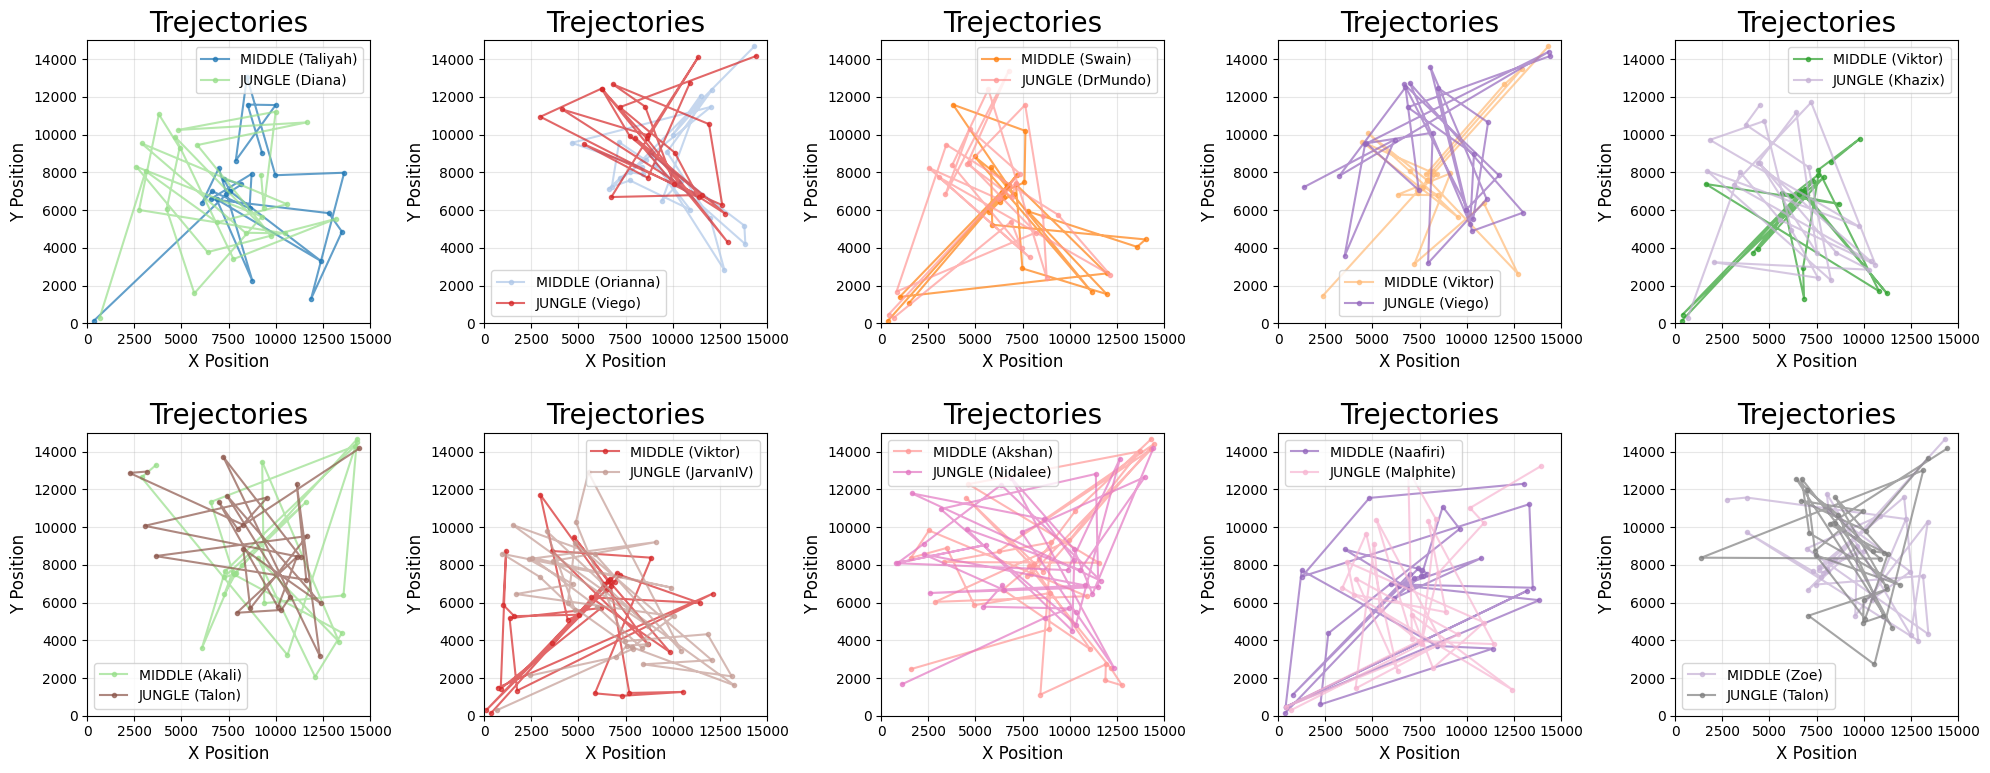

In [60]:
import matplotlib.pyplot as plt

n_samples = 10
roles = ['MIDDLE', 'JUNGLE']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

colors = plt.cm.tab20(range(n_samples+5))

for i in range(len(roles)):
    role = roles[i]
    for idx in range(n_samples):
        ax = axes[idx]
        data_by_role = data_deleted[data_deleted['role'] == role]

        x_positions = [data_by_role.iloc[idx][f'x{i}'] for i in range(40)]
        y_positions = [data_by_role.iloc[idx][f'y{i}'] for i in range(40)]

        champion = data_by_role.iloc[idx]['champion']

        ax.plot(x_positions, y_positions, '-o', color= colors[idx + 5*i], markersize=3, linewidth=1.5, label=f"{role} ({champion})", alpha=0.7)

        ax.set_title(f'Trejectories', fontsize=20)
        ax.set_xlabel('X Position', fontsize=12)
        ax.set_ylabel('Y Position', fontsize=12)
        ax.set_xlim(0, 15000)
        ax.set_ylim(0, 15000)
        ax.grid(True, alpha=0.3)
        ax.legend()
        ax.set_aspect('equal')

plt.tight_layout()
plt.show()

Random Forest

In [61]:
from sklearn.ensemble import RandomForestClassifier

position_cols = [col for col in data_deleted.columns if col.startswith(('x', 'y'))]
X = data_deleted[position_cols] 
y = data_deleted['role']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8)

model_rf = RandomForestClassifier(n_estimators=20)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

print("="*50)
print("RANDOM FOREST")
print("="*50)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy: {acc_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\n" + "="*70)
print(f"{'Model':<20} {'Accuracy':<15}")
print("-"*70)
print(f"{'Mapping':<20} {acc_map:.4f}")
print(f"{'Logistic Regression':<20} {acc_lr:.4f}")
print(f"{'Random Forest':<20} {acc_rf:.4f}")
print("="*70)

RANDOM FOREST
Accuracy: 0.9997

Classification Report:
              precision    recall  f1-score   support

      BOTTOM       1.00      1.00      1.00     77167
      JUNGLE       1.00      1.00      1.00     77268
      MIDDLE       1.00      1.00      1.00     77113
         TOP       1.00      1.00      1.00     76961
     UTILITY       1.00      1.00      1.00     77242

    accuracy                           1.00    385751
   macro avg       1.00      1.00      1.00    385751
weighted avg       1.00      1.00      1.00    385751


Model                Accuracy       
----------------------------------------------------------------------
Mapping              0.8344
Logistic Regression  0.8347
Random Forest        0.9997


Random Forest - first 20 positions

In [62]:
position_cols = [f'x{i}' for i in range(20)] + [f'y{i}' for i in range(20)]
X = data_deleted[position_cols]
y = data_deleted['role']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8)

model_rf = RandomForestClassifier(n_estimators=10)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

print("="*50)
print("RANDOM FOREST 20")
print("="*50)
acc_rf20 = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy: {acc_rf20:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\n" + "="*70)
print(f"{'Model':<30} {'Accuracy':<15}")
print("-"*70)
print(f"{'Mapping':<30} {acc_map:.4f}")
print(f"{'Logistic Regression':<30} {acc_lr:.4f}")
print(f"{'Random Forest':<30} {acc_rf:.4f}")
print(f"{'Random Forest - first 20':<30} {acc_rf20:.4f}")
print("="*70)

RANDOM FOREST 20
Accuracy: 0.9997

Classification Report:
              precision    recall  f1-score   support

      BOTTOM       1.00      1.00      1.00     77239
      JUNGLE       1.00      1.00      1.00     77192
      MIDDLE       1.00      1.00      1.00     77008
         TOP       1.00      1.00      1.00     77127
     UTILITY       1.00      1.00      1.00     77185

    accuracy                           1.00    385751
   macro avg       1.00      1.00      1.00    385751
weighted avg       1.00      1.00      1.00    385751


Model                          Accuracy       
----------------------------------------------------------------------
Mapping                        0.8344
Logistic Regression            0.8347
Random Forest                  0.9997
Random Forest - first 20       0.9997


Random Forest - firts 5 positions

In [ ]:
position_cols = [f'x{i}' for i in range(5)] + [f'y{i}' for i in range(5)]
X = data_deleted[position_cols]
y = data_deleted['role']



X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model_rf = RandomForestClassifier(n_estimators=10)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

print("="*50)
print("RANDOM FOREST 20")
print("="*50)
acc_rf20 = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy: {acc_rf20:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\n" + "="*70)
print(f"{'Model':<30} {'Accuracy':<15}")
print("-"*70)
print(f"{'Mapping':<30} {acc_map:.4f}")
print(f"{'Logistic Regression':<30} {acc_lr:.4f}")
print(f"{'Random Forest':<30} {acc_rf:.4f}")
print(f"{'Random Forest - first 20':<30} {acc_rf20:.4f}")
print("="*70)

RANDOM FOREST 20
Accuracy: 0.4044

Classification Report:
              precision    recall  f1-score   support

      BOTTOM       0.35      0.39      0.37     19258
      JUNGLE       0.43      0.48      0.45     19215
      MIDDLE       0.29      0.26      0.28     19216
         TOP       0.65      0.65      0.65     19420
     UTILITY       0.28      0.24      0.26     19329

    accuracy                           0.40     96438
   macro avg       0.40      0.40      0.40     96438
weighted avg       0.40      0.40      0.40     96438


Model                          Accuracy       
----------------------------------------------------------------------
Mapping                        0.8344
Logistic Regression            0.8347
Random Forest                  0.9997
Random Forest - first 20       0.4044


Random Forest - first 20 positions + distance to 0,0

In [63]:
import numpy as np 

position_cols = [f'x{i}' for i in range(20)] + [f'y{i}' for i in range(20)]
X = data_deleted[position_cols].copy()
y = data_deleted['role']

for i in range(20):
    X[f'dist{i}'] = np.sqrt(X[f'x{i}']**2 + X[f'y{i}']**2)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8)

model_rf = RandomForestClassifier(n_estimators=20)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

print("="*50)
print("RANDOM FOREST 20")
print("="*50)
acc_rf20_dist = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy: {acc_rf20_dist:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\n" + "="*70)
print(f"{'Model':<40} {'Accuracy':<15}")
print("-"*70)
print(f"{'Mapping':<40} {acc_map:.4f}")
print(f"{'Logistic Regression':<40} {acc_lr:.4f}")
print(f"{'Random Forest':<40} {acc_rf:.4f}")
print(f"{'Random Forest - first 20':<40} {acc_rf20:.4f}")
print(f"{'Random Forest - first 20 + distance':<40} {acc_rf20_dist:.4f}")
print("="*70)

RANDOM FOREST 20
Accuracy: 0.9998

Classification Report:
              precision    recall  f1-score   support

      BOTTOM       1.00      1.00      1.00     77120
      JUNGLE       1.00      1.00      1.00     77168
      MIDDLE       1.00      1.00      1.00     77203
         TOP       1.00      1.00      1.00     77170
     UTILITY       1.00      1.00      1.00     77090

    accuracy                           1.00    385751
   macro avg       1.00      1.00      1.00    385751
weighted avg       1.00      1.00      1.00    385751


Model                                    Accuracy       
----------------------------------------------------------------------
Mapping                                  0.8344
Logistic Regression                      0.8347
Random Forest                            0.9997
Random Forest - first 20                 0.9997
Random Forest - first 20 + distance      0.9998


Random forest - first 20 positions + team

In [64]:
import numpy as np 

position_cols = [f'x{i}' for i in range(20)] + [f'y{i}' for i in range(20)]
X = data_deleted[position_cols].copy()
X['team'] = data_deleted['team']
y = data_deleted['role']

for i in range(20):
    X[f'dist{i}'] = np.sqrt(X[f'x{i}']**2 + X[f'y{i}']**2)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8)

model_rf = RandomForestClassifier(n_estimators=20)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

print("="*50)
print("RANDOM FOREST 20")
print("="*50)
acc_rf20_team = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy: {acc_rf20_dist:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\n" + "="*70)
print(f"{'Model':<20} {'Accuracy':<15}")
print("-"*70)
print(f"{'Mapping':<40} {acc_map:.4f}")
print(f"{'Logistic Regression':<40} {acc_lr:.4f}")
print(f"{'Random Forest':<40} {acc_rf:.4f}")
print(f"{'Random Forest - first 20':<40} {acc_rf20:.4f}")
print(f"{'Random Forest - first 20 + distance':<40} {acc_rf20_dist:.4f}")
print(f"{'Random Forest - first 20 + team':<40} {acc_rf20_team:.4f}")
print("="*70)

RANDOM FOREST 20
Accuracy: 0.9998

Classification Report:
              precision    recall  f1-score   support

      BOTTOM       1.00      1.00      1.00     77062
      JUNGLE       1.00      1.00      1.00     77240
      MIDDLE       1.00      1.00      1.00     77145
         TOP       1.00      1.00      1.00     77018
     UTILITY       1.00      1.00      1.00     77286

    accuracy                           1.00    385751
   macro avg       1.00      1.00      1.00    385751
weighted avg       1.00      1.00      1.00    385751


Model                Accuracy       
----------------------------------------------------------------------
Mapping                                  0.8344
Logistic Regression                      0.8347
Random Forest                            0.9997
Random Forest - first 20                 0.9997
Random Forest - first 20 + distance      0.9998
Random Forest - first 20 + team          0.9998
